In [1]:
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.preprocessing import StandardScaler



In [ ]:
df = pd.read_csv('../../datasets/house_data.csv')
df.sample(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
17780,4322200220,20150421T000000,675000,3,2.75,3370,5350,1.5,0,1,...,7,2310,1060,1910,0,98136,47.5373,-122.390,1720,5618
4330,3343901340,20140804T000000,330000,3,1.75,1460,9261,1.0,0,0,...,7,1460,0,1985,0,98056,47.5155,-122.189,1550,8800
11627,6117500160,20150317T000000,425000,3,1.50,1570,12412,1.0,0,3,...,8,1570,0,1954,0,98166,47.4380,-122.349,2130,12412
4770,7686202580,20150213T000000,196900,3,1.00,1270,7500,1.0,0,0,...,6,1270,0,1954,0,98198,47.4214,-122.316,1250,8000
102,7214720075,20141212T000000,699950,3,2.25,2190,107593,2.0,0,0,...,8,2190,0,1983,0,98077,47.7731,-122.080,2570,47777


In [3]:
df.shape

(21613, 21)

In [4]:
df = df.replace('?', np.nan)

In [5]:
df = df.dropna()

In [6]:
df.shape

(21613, 21)

#### Remove colunas não necessárias ao modelo

In [7]:
df.drop(['id', 'date'], axis=1, inplace=True)

In [8]:
df.sample(5)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
299,267500,3,1.75,1590,11914,1.0,0,2,3,7,1090,500,1957,0,98188,47.4427,-122.274,1630,9052
7079,485000,3,2.50,1500,5412,1.0,0,0,5,7,900,600,1920,0,98136,47.5499,-122.394,1090,5412
6730,385000,4,3.25,1790,2460,2.0,0,0,4,7,1100,690,2000,0,98106,47.5340,-122.346,1260,4040
320,819900,5,2.75,3150,7119,2.0,0,0,3,9,3150,0,2013,0,98052,47.6759,-122.151,1560,8384
10924,305000,4,2.25,2210,9371,2.0,0,0,4,8,2210,0,1968,0,98032,47.3634,-122.279,2300,11584


In [9]:
df.dtypes

price              int64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [10]:
df['age'] = datetime.datetime.now().year - pd.to_numeric(df['yr_built'])
df[['price', 'bedrooms', 'bathrooms', 'age', 'yr_renovated']].sample(5)

,price,bedrooms,bathrooms,age,yr_renovated
5739,1620500,3,2.50,66,0
3842,576750,3,2.00,60,0
7553,310000,4,2.25,60,0
16420,352750,2,1.75,18,0
19099,707000,3,1.50,107,0


In [11]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,age
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652,54.994864
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631,29.373411
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000,11.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000,29.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000,51.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000,75.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000,126.000000


Text(0, 0.5, 'Price')

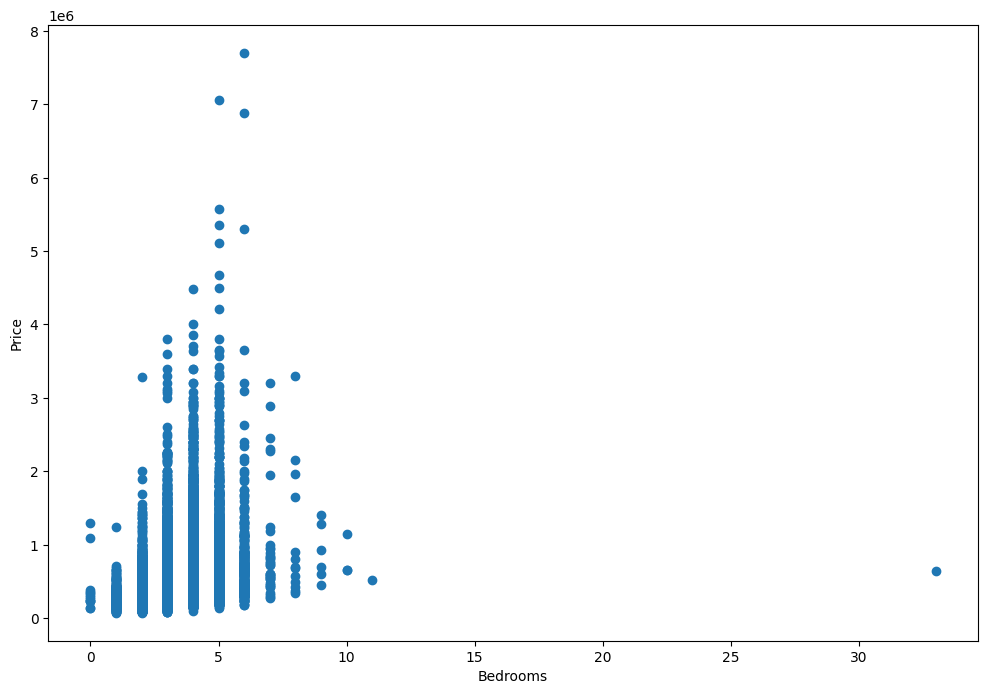

In [12]:
fig, ax = plt.subplots(figsize=(12, 8))

plt.scatter(df['bedrooms'], df['price'])

plt.xlabel('Bedrooms')
plt.ylabel('Price')

Text(0, 0.5, 'Price')

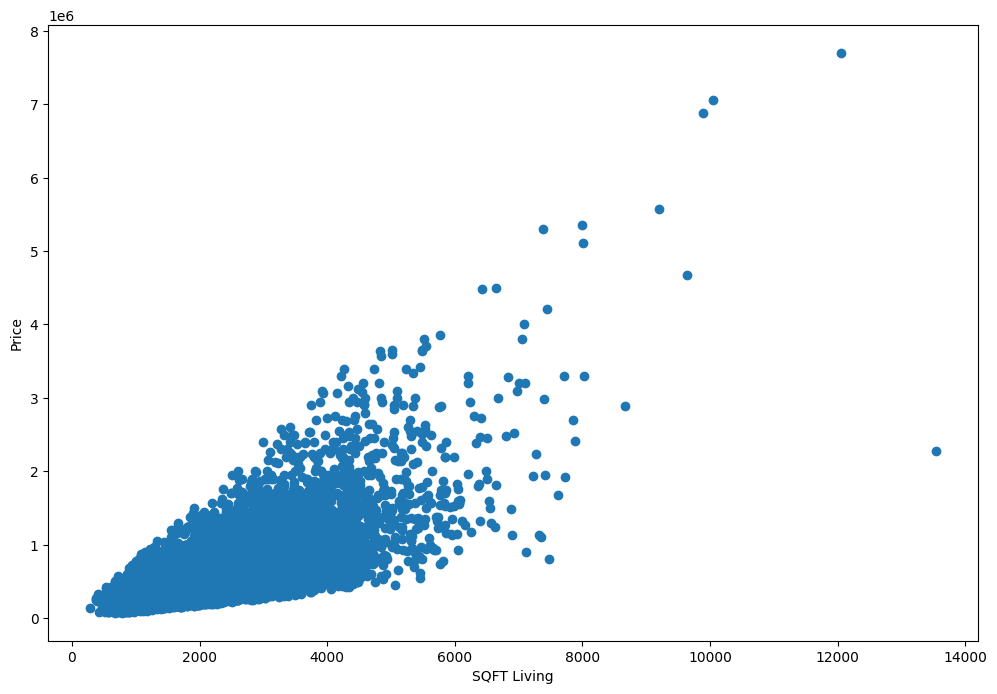

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))

plt.scatter(df['sqft_living'], df['price'])

plt.xlabel('SQFT Living')
plt.ylabel('Price')

In [14]:
house_corr = df.corr()
house_corr

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,age
price,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447,-0.054012
bedrooms,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244,-0.154178
bathrooms,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175,-0.506019
sqft_living,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286,-0.318049
sqft_lot,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557,-0.053080
floors,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269,-0.489319
waterfront,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703,0.026161
view,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575,0.053440
condition,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406,0.361417
grade,0.667434,0.356967,0.664983,0.762704,0.113621,0.458183,0.082775,0.251321,-0.144674,1.000000,0.755923,0.168392,0.446963,0.014414,-0.184862,0.114084,0.198372,0.713202,0.119248,-0.446963


<Axes: >

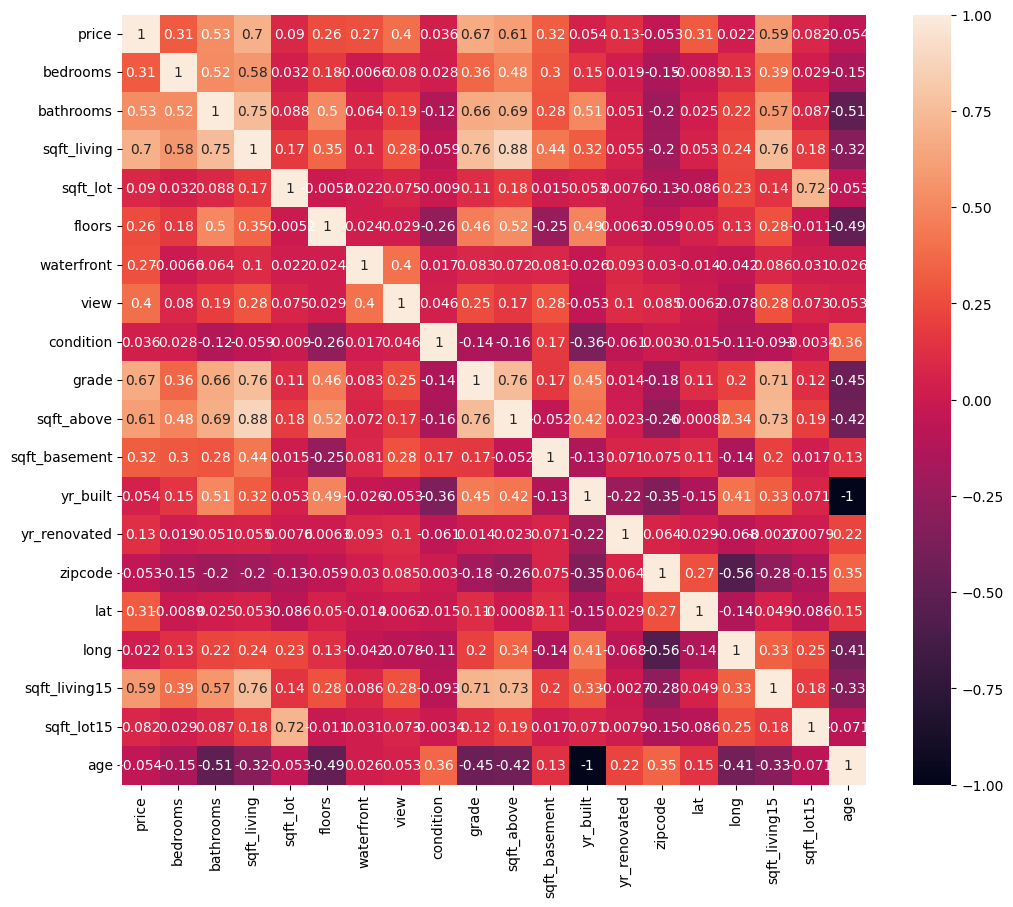

In [15]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(house_corr, annot=True)

In [16]:
df = df.sample(frac=1).reset_index(drop=True)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,age
0,299000,3,2.25,1940,9100,1.0,0,0,4,8,1630,310,1966,0,98023,47.3133,-122.364,2080,9100,60
1,268000,4,1.75,1680,9966,1.0,0,0,3,7,1100,580,1977,0,98198,47.3923,-122.311,2400,10369,49
2,450000,3,1.75,1640,13500,1.0,0,0,3,7,1110,530,1940,0,98125,47.7164,-122.304,1770,12600,86
3,549000,2,1.00,1510,11165,1.5,0,0,4,7,1510,0,1921,0,98133,47.7212,-122.331,2210,8851,105
4,245000,3,1.50,1260,7964,1.0,0,0,4,7,1260,0,1955,0,98148,47.4307,-122.334,1510,8776,71


In [17]:
df.shape

(21613, 20)

In [26]:
from sklearn.model_selection import train_test_split

X = df[['sqft_living']]
Y = df['price']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.4)

In [27]:
x_train.sample(5)

,sqft_living
4501,2350
12739,2980
15944,1040
6723,1560
12174,1010


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Transformando de volta em DataFrame para manter os nomes das colunas
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)
linear_model = LinearRegression().fit(x_train_scaled, y_train)

In [29]:
print("Modelo Linear Simples: Intercept = {:.5}".format(linear_model.intercept_))
print("Modelo Linear Simples: Coefficient = {:.5}".format(linear_model.coef_[0]))
print("Modelo Linear Simples: Price = {:.5} + {:.5}(Living Area)".format(linear_model.intercept_, linear_model.coef_[0]))

Modelo Linear Simples: Intercept = 5.4434e+05
Modelo Linear Simples: Coefficient = 2.6371e+05
Modelo Linear Simples: Price = 5.4434e+05 + 2.6371e+05(Living Area)


In [30]:
print('Training score: ', linear_model.score(x_train_scaled, y_train))

Training score:  0.4952346245036321


In [31]:
y_pred = linear_model.predict(x_test_scaled)

In [32]:
from sklearn.metrics import r2_score
print('Testing score: ', r2_score(y_test, y_pred))

Testing score:  0.4881314363328014


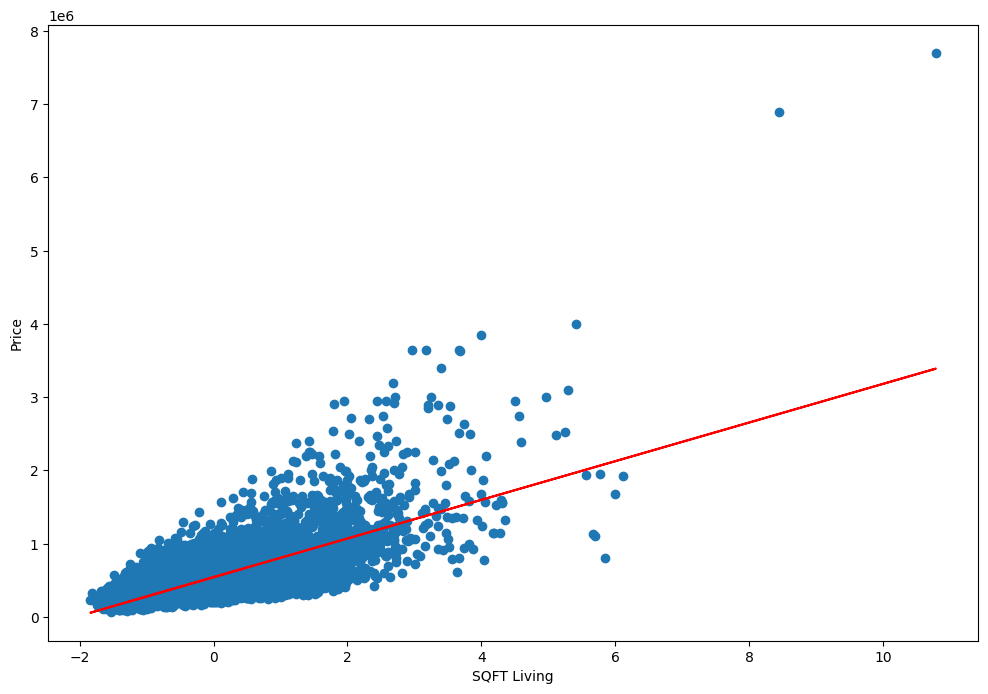

In [33]:
fig, ax = plt.subplots(figsize=(12, 8))

plt.scatter(x_test_scaled, y_test)
plt.plot(x_test_scaled, y_pred, color='r')

plt.xlabel('SQFT Living')
plt.ylabel('Price')
plt.show()

In [34]:
df = df.sample(frac=1).reset_index(drop=True)

In [35]:
X = df[['sqft_living']]
Y = df['price']
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.1)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Transformando de volta em DataFrame para manter os nomes das colunas
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

linear_model = LinearRegression().fit(x_train_scaled, y_train)
print("Modelo Linear Simples: Intercept = {:.5}".format(linear_model.intercept_))
print("Modelo Linear Simples: Coefficient = {:.5}".format(linear_model.coef_[0]))
print("Modelo Linear Simples: Price = {:.5} + {:.5}(Living Area)".format(linear_model.intercept_, linear_model.coef_[0]))

Modelo Linear Simples: Intercept = 5.3944e+05
Modelo Linear Simples: Coefficient = 2.588e+05
Modelo Linear Simples: Price = 5.3944e+05 + 2.588e+05(Living Area)


In [36]:
print('Training score: ', linear_model.score(x_train_scaled, y_train))

Training score:  0.4943084812821936


In [37]:
y_pred = linear_model.predict(x_test_scaled)

In [38]:
print('Testing score: ', r2_score(y_test, y_pred))

Testing score:  0.4787403829266772


#### Regressão Linear multivariada

In [39]:
X = df[['bathrooms', 'sqft_living', 'grade', 'sqft_above', 'sqft_living15']]
Y = df['price']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [40]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Transformando de volta em DataFrame para manter os nomes das colunas
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

linear_model = LinearRegression().fit(x_train_scaled, y_train)


In [41]:
print('Training score: ', linear_model.score(x_train_scaled, y_train))

Training score:  0.5393608132392737


In [42]:
predictors = x_train_scaled.columns
coef = pd.Series(linear_model.coef_, predictors).sort_values()
print("Modelo Linear: Intercept = {:.5}".format(linear_model.intercept_))
print("Modelo Linear: Coefficients:")
print(coef)

Modelo Linear: Intercept = 5.3821e+05
Modelo Linear: Coefficients:
sqft_above       -62477.387426
bathrooms        -27015.737302
sqft_living15     11488.477376
grade            129591.518037
sqft_living      225748.963516
dtype: float64


In [43]:
y_pred = linear_model.predict(x_test_scaled)

In [44]:
print('Testing score: ', r2_score(y_test, y_pred))

Testing score:  0.5636836562125935


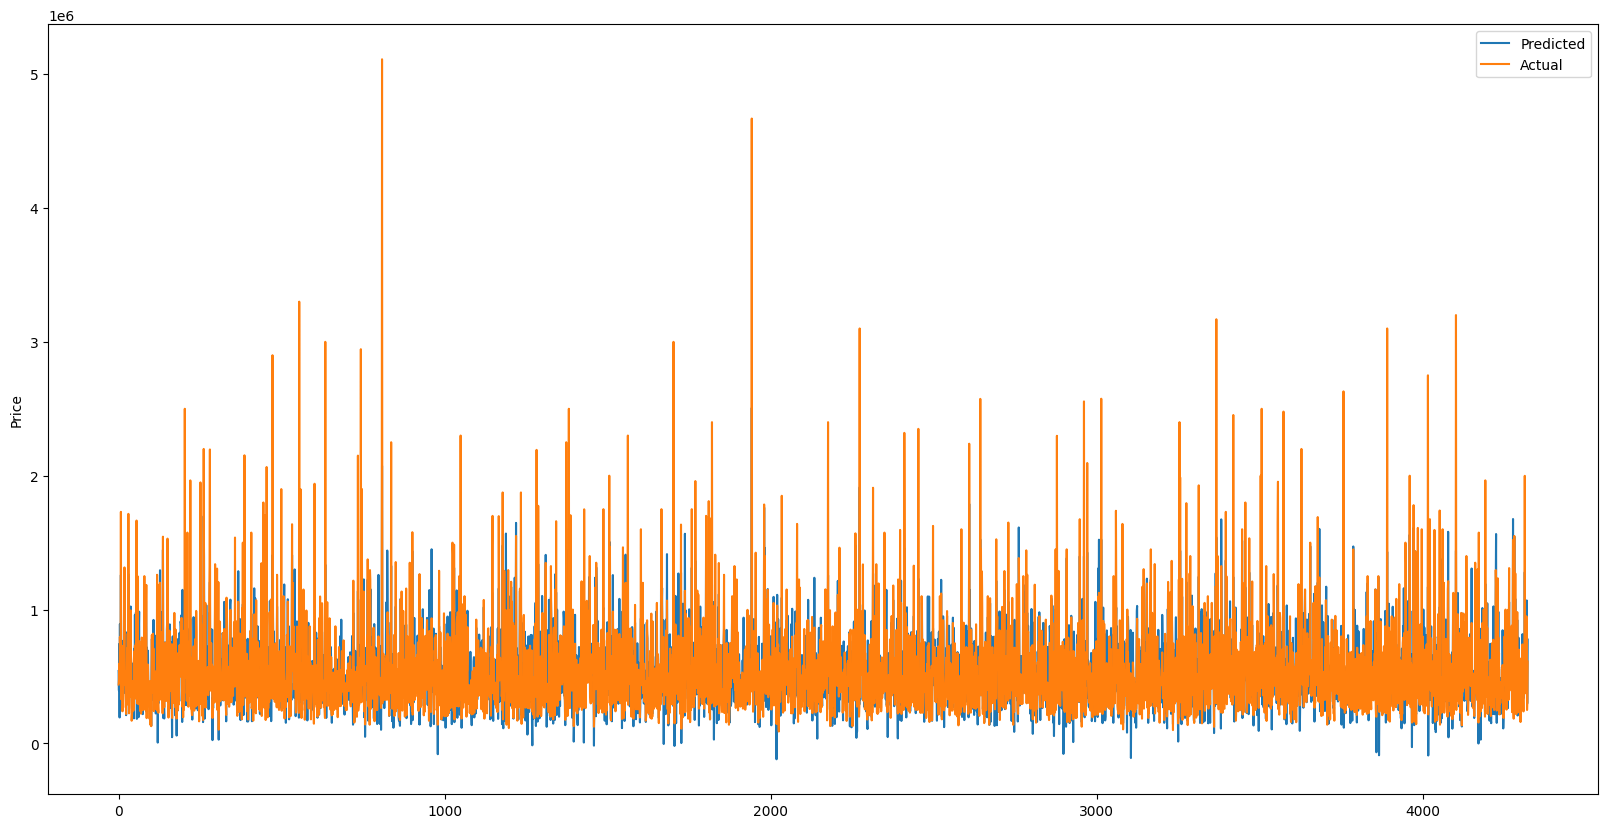

In [45]:
plt.figure(figsize = (20,10))

plt.plot(y_pred, label='Predicted')
plt.plot(y_test.values, label='Actual')

plt.ylabel('Price')

plt.legend()
plt.show()

In [46]:
df['floors'].unique()

array([1. , 3. , 2. , 1.5, 2.5, 3.5])

In [159]:
floors = [
    "1.0",
    "1.5",
    "2.0",
    "2.5",
    "3.0",
    "3.5"
]

In [160]:
from sklearn import preprocessing
label_encoding = preprocessing.LabelEncoder()
label_encoding = label_encoding.fit(floors)

In [161]:
df['floors'] = label_encoding.transform(df['floors'].astype(str))

In [162]:
df['waterfront'].unique()

array([0, 1])

In [163]:
waterfront = [
    "0",
    "1"
]

In [164]:
df['view'].unique()

array([0, 2, 4, 3, 1])

In [165]:
view = [
    "0",
    "1",
    "2",
    "3",
    "4"
]

In [50]:
df = pd.get_dummies(df, columns=['waterfront', 'view'])

In [51]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,sqft_basement,...,sqft_living15,sqft_lot15,age,waterfront_0,waterfront_1,view_0,view_1,view_2,view_3,view_4
0,480000,5,2.25,2240,5500,1.0,3,7,1490,750,...,2010,6050,67,True,False,True,False,False,False,False
1,1400000,5,3.25,4140,32700,1.0,3,10,2190,1950,...,3220,22077,53,True,False,False,False,False,False,True
2,520000,2,2.25,1530,981,3.0,3,8,1480,50,...,1530,1282,20,True,False,True,False,False,False,False
3,321000,3,2.25,1347,1292,3.0,3,7,1347,0,...,1480,1865,16,True,False,True,False,False,False,False
4,375000,2,2.25,1640,2240,2.0,3,8,1640,0,...,1640,2240,46,True,False,True,False,False,False,False


In [52]:
X = df[['bathrooms', 'sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'floors', 'waterfront_0', 'waterfront_1', \
              'view_0', 'view_1', 'view_2', 'view_3', 'view_4']]
Y = df['price']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [53]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Transformando de volta em DataFrame para manter os nomes das colunas
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

linear_model = LinearRegression().fit(x_train_scaled, y_train)

In [54]:
print('Training score: ', linear_model.score(x_train_scaled, y_train))

Training score:  0.5966936971370917


In [55]:
predictors = x_train.columns
coef = pd.Series(linear_model.coef_, predictors).sort_values()

print(coef)

sqft_above       -39414.051425
waterfront_0     -26279.344862
bathrooms        -24518.369461
view_0           -22604.315486
floors            -1509.959477
view_2             3979.829686
sqft_living15      4376.756354
view_1             6620.221333
view_3            12762.665846
waterfront_1      26279.344862
view_4            26304.997784
grade            121767.959068
sqft_living      194931.044029
dtype: float64


In [56]:
y_pred = linear_model.predict(x_test_scaled)

In [57]:
print('Testing score: ', r2_score(y_test, y_pred))

Testing score:  0.585611680789458


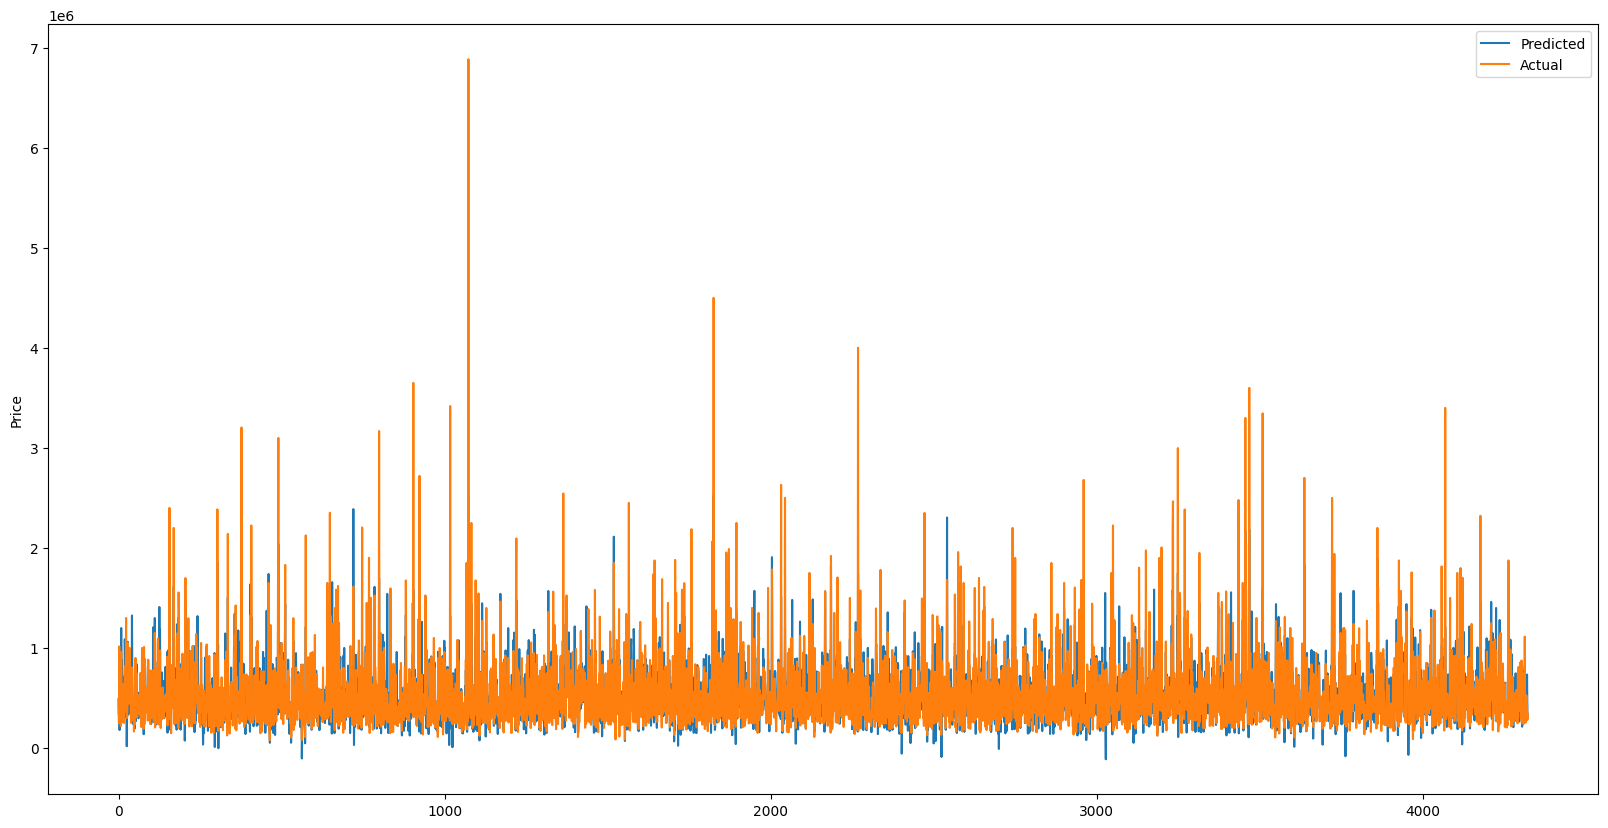

In [58]:
plt.figure(figsize = (20,10))

plt.plot(y_pred, label='Predicted')
plt.plot(y_test.values, label='Actual')

plt.ylabel('Price')

plt.legend()
plt.show()

In [59]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
Y = df['price']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [60]:
x_train.shape, x_test.shape

((17290, 24), (4323, 24))

In [61]:
y_train.shape, y_test.shape

((17290,), (4323,))

In [62]:
from sklearn.linear_model import LinearRegression
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Transformando de volta em DataFrame para manter os nomes das colunas
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

linear_model = LinearRegression(fit_intercept=True).fit(x_train_scaled, y_train)

In [63]:
print("Training_score : " , linear_model.score(x_train_scaled, y_train))

Training_score :  0.7014063188209478


In [64]:
y_pred = linear_model.predict(x_test_scaled)

In [65]:
from sklearn.metrics import r2_score

print("Testing_score : ", r2_score(y_test, y_pred))

Testing_score :  0.6999684355757045


In [66]:
df_pred_actual = pd.DataFrame({'predicted': y_pred, 'actual': y_test})

df_pred_actual.head(10)

,predicted,actual
3929,209172.646431,161500
19676,236632.624030,269000
9101,537873.946342,468000
17578,986259.935037,980000
11332,381078.739121,346290
19815,434348.315667,604000
5285,521020.048326,560000
2356,475495.923789,618000
2497,644495.354104,700000
16223,191657.029387,193000


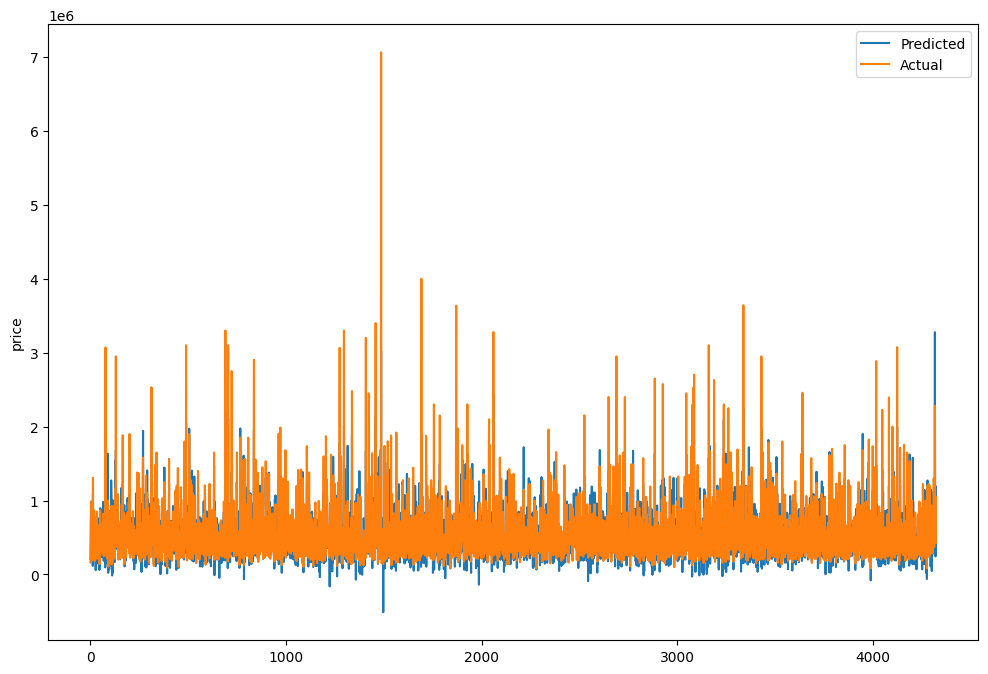

In [67]:
plt.figure(figsize = (12, 8))

plt.plot(y_pred, label='Predicted')
plt.plot(y_test.values, label='Actual')

plt.ylabel('price')

plt.legend()
plt.show()